In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

In [2]:
df = pd.read_csv('bmw.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  str    
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  str    
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  str    
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), str(3)
memory usage: 758.2 KB


In [5]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [6]:
df.nunique()

model             24
year              25
price           3777
transmission       3
mileage         8086
fuelType           5
tax               38
mpg              102
engineSize        17
dtype: int64

In [7]:
styled = (df.describe().T
    .style
    .background_gradient(cmap="viridis")   
    .format("{:.2f}")                     
    .set_caption("Statistical Summary")
    .set_properties(**{
        "border": "1px solid white",
        "padding": "6px",
        "font-size": "12px"
    }))
styled

,count,mean,std,min,25%,50%,75%,max
year,10781.00,2017.08,2.35,1996.00,2016.00,2017.00,2019.00,2020.00
price,10781.00,22733.41,11415.53,1200.00,14950.00,20462.00,27940.00,123456.00
mileage,10781.00,25496.99,25143.19,1.00,5529.00,18347.00,38206.00,214000.00
tax,10781.00,131.70,61.51,0.00,135.00,145.00,145.00,580.00
mpg,10781.00,56.40,31.34,5.50,45.60,53.30,62.80,470.80
engineSize,10781.00,2.17,0.55,0.00,2.00,2.00,2.00,6.60


In [8]:
df[df['fuelType'] == 'Electric']

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
8375,i3,2017,18999,Automatic,20321,Electric,135,470.8,0.0
8400,i3,2016,18999,Automatic,9990,Electric,0,470.8,0.0
8835,i3,2015,17400,Automatic,29465,Electric,0,470.8,1.0


In [10]:
import warnings
warnings.filterwarnings("ignore")


cols_for_count = []
cols_for_hist = []

for col in df.columns:
    if df[col].nunique() <= 15:
        cols_for_count.append(col)
    else:
        cols_for_hist.append(col)


for i, col in enumerate(cols_for_count, 1):
    print(f"{i:>2}. {col:<25} | unique: {df[col].nunique()}")



for i, col in enumerate(cols_for_hist, 1):
    print(f"{i:>2}. {col:<25} | unique: {df[col].nunique()}")

print(f"Total countplot columns : {len(cols_for_count)}")
print(f"Total histogram columns : {len(cols_for_hist)}")

 1. transmission              | unique: 3
 2. fuelType                  | unique: 5
 1. model                     | unique: 24
 2. year                      | unique: 25
 3. price                     | unique: 3777
 4. mileage                   | unique: 8086
 5. tax                       | unique: 38
 6. mpg                       | unique: 102
 7. engineSize                | unique: 17
Total countplot columns : 2
Total histogram columns : 7


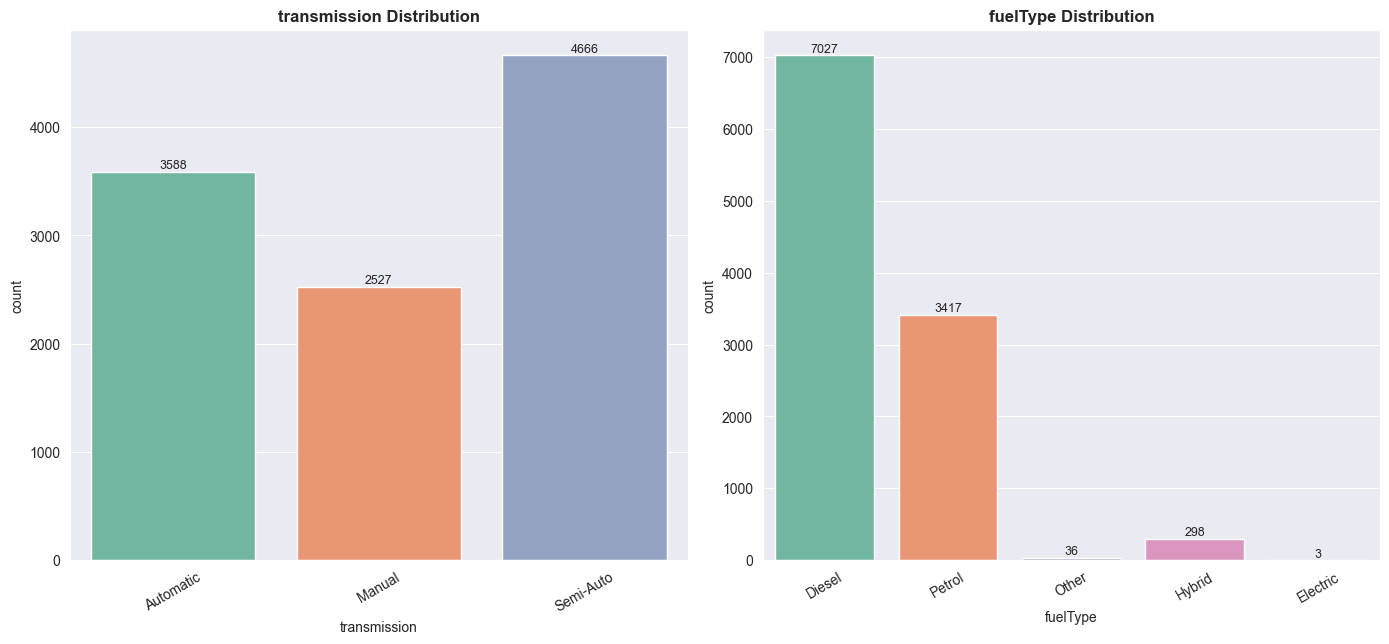

In [11]:
sns.set_style("darkgrid")

fig,axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i,col in enumerate(cols_for_count):
    ax = sns.countplot(
        data=df,
        x=col,
        ax=axes[i],
        palette="Set2")
    
    axes[i].set_title(f"{col} Distribution", fontsize=12, weight="bold")
    axes[i].tick_params(axis='x', rotation=30)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2., height),
            ha="center",
            va="bottom",
            fontsize=9)
if len(cols_for_count) < len(axes):
    for j in range(len(cols_for_count), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('Distribution.png')
plt.show()

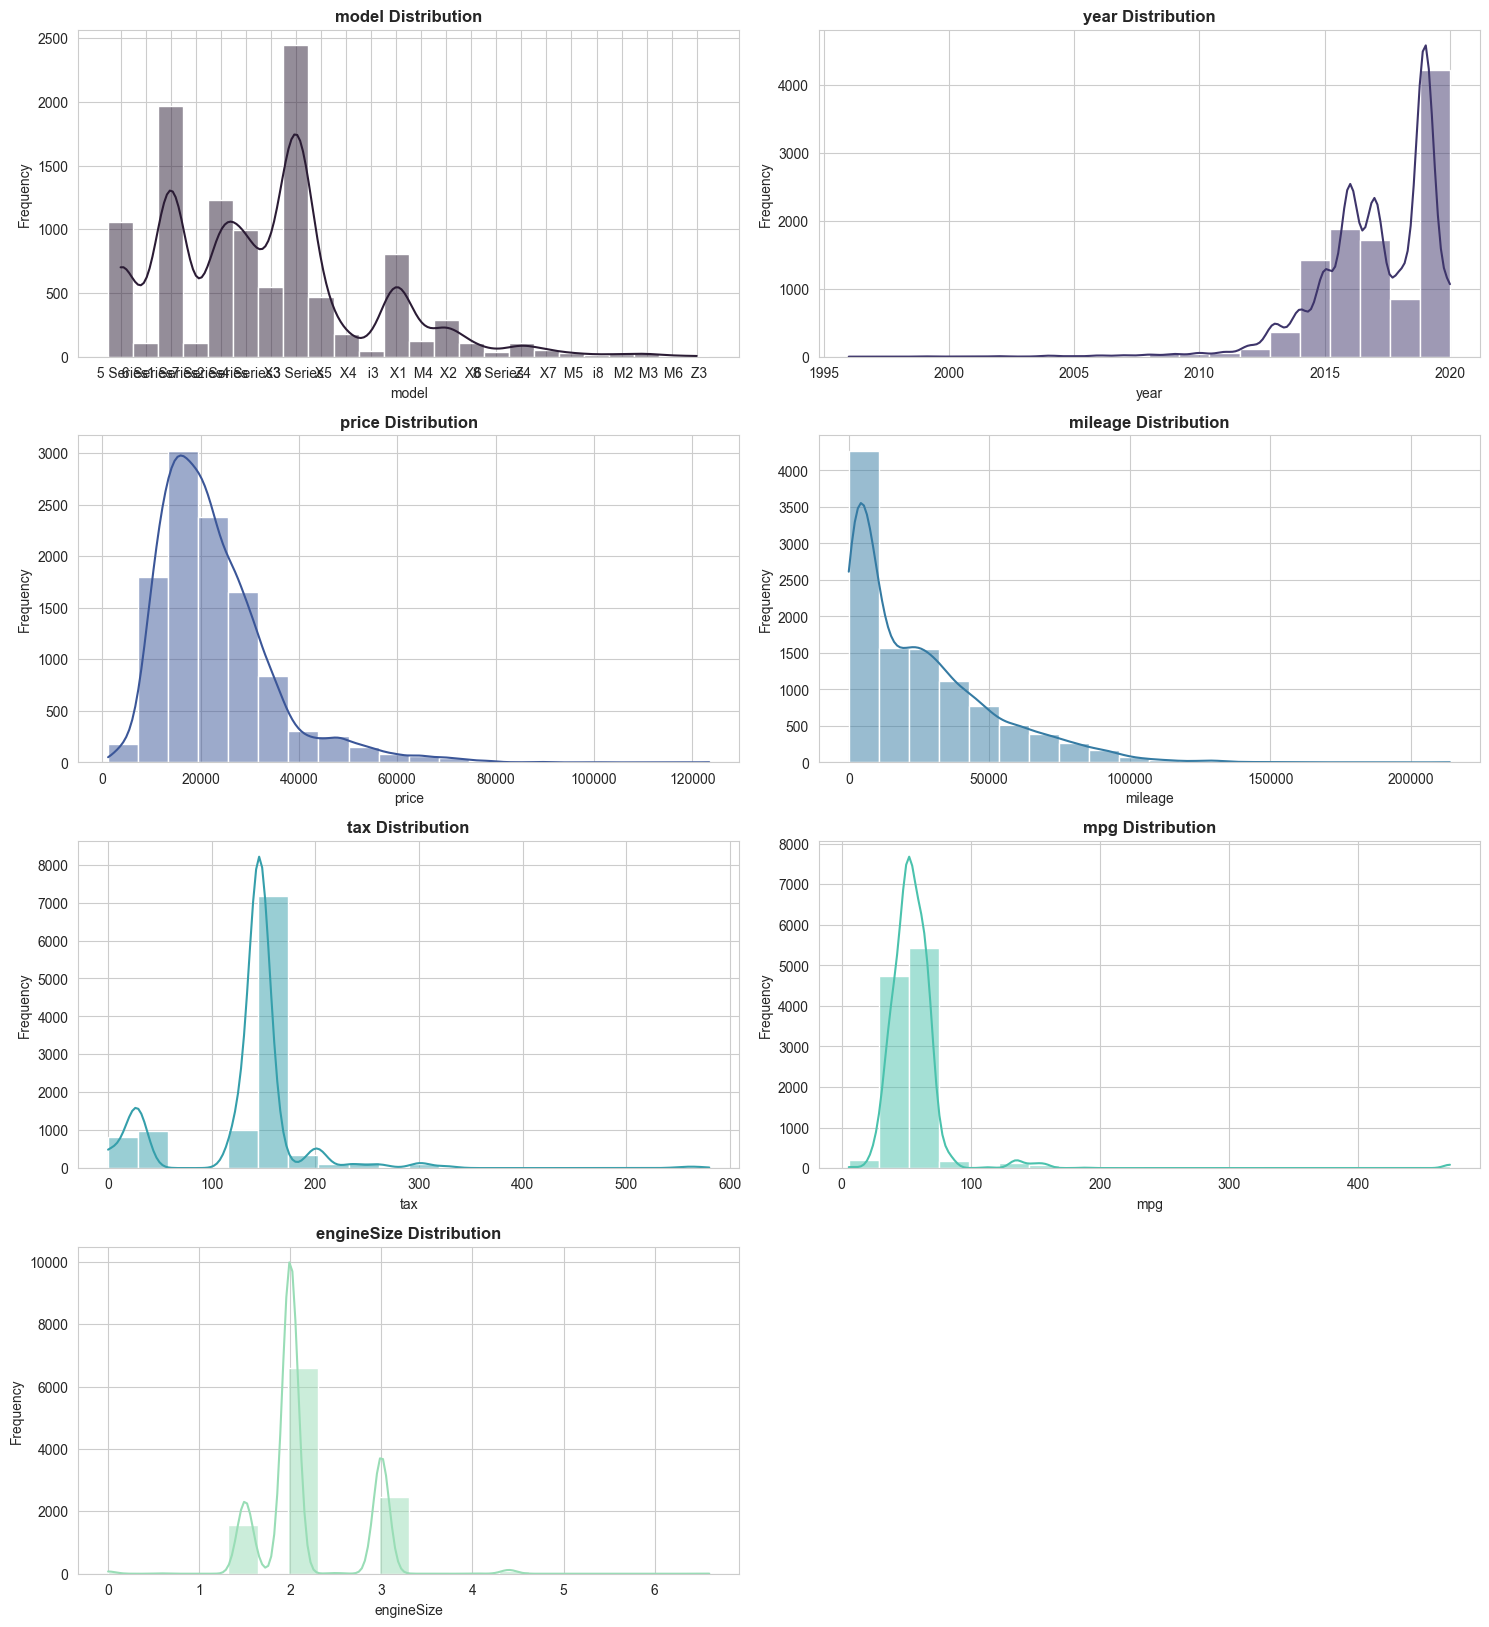

In [12]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(5, 2, figsize=(15, 20))
axes = axes.flatten()

palette = sns.color_palette("mako", n_colors=len(cols_for_hist))

for i, col in enumerate(cols_for_hist):
    ax = sns.histplot(
        data=df,
        x=col,
        ax=axes[i],
        bins=20,
        kde=True,
        color=palette[i])
    
    axes[i].set_title(f"{col} Distribution", fontsize=12, weight="bold")
    axes[i].set_ylabel("Frequency")

if len(cols_for_hist) < len(axes):
    for j in range(len(cols_for_hist), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('Frequency_and_distributions.png')
plt.show()

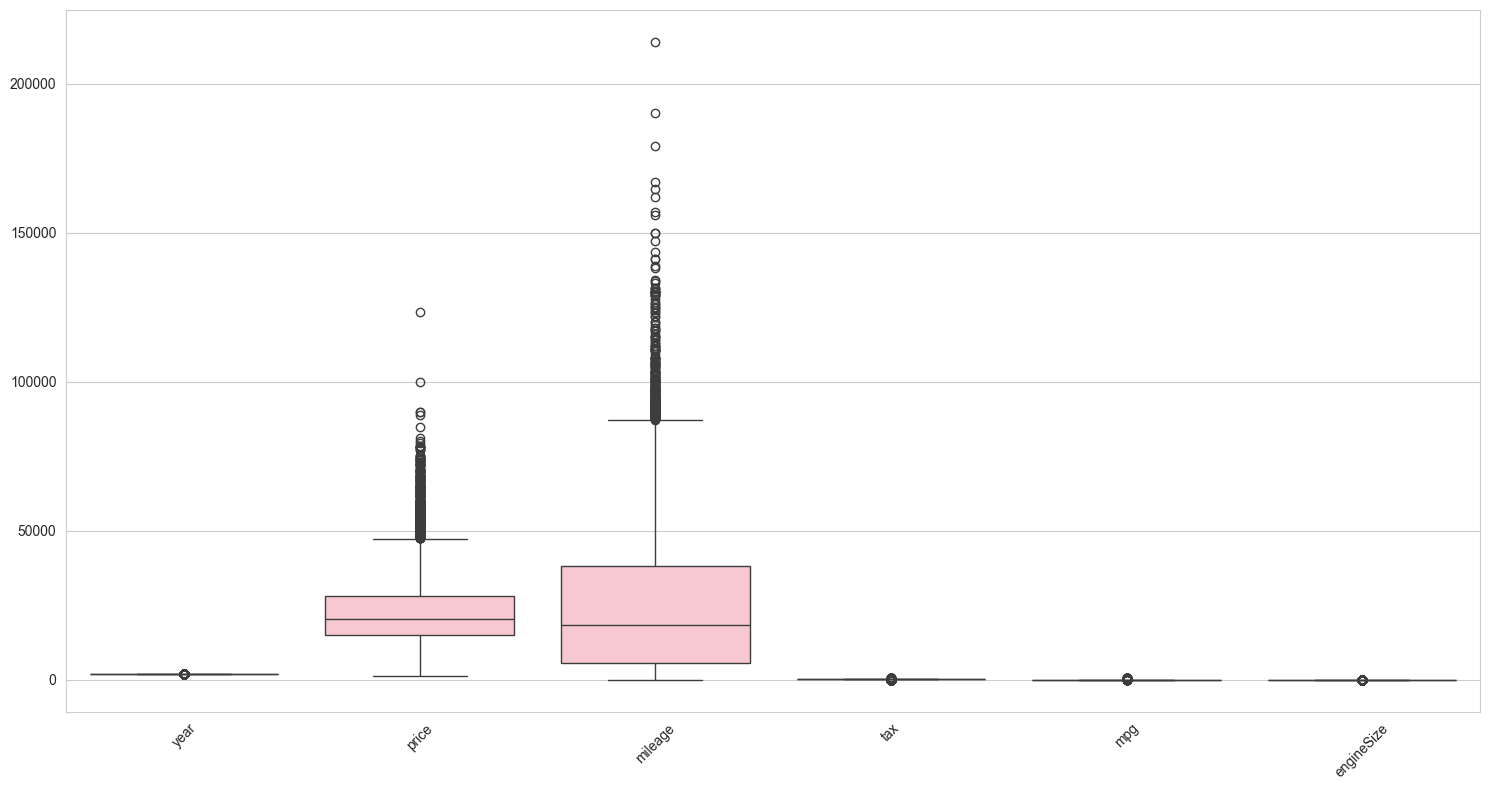

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,8))
sns.boxplot(data=df[num_cols], color = 'pink')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Boxplotting.png')
plt.show()

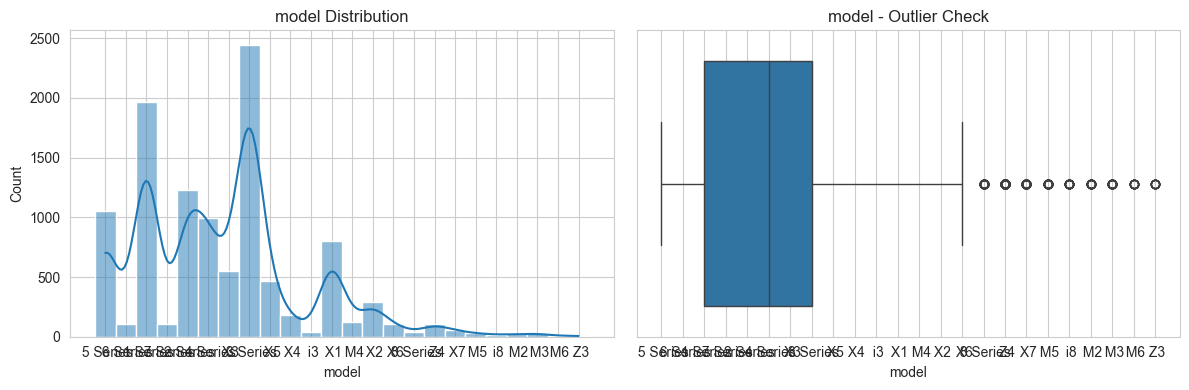

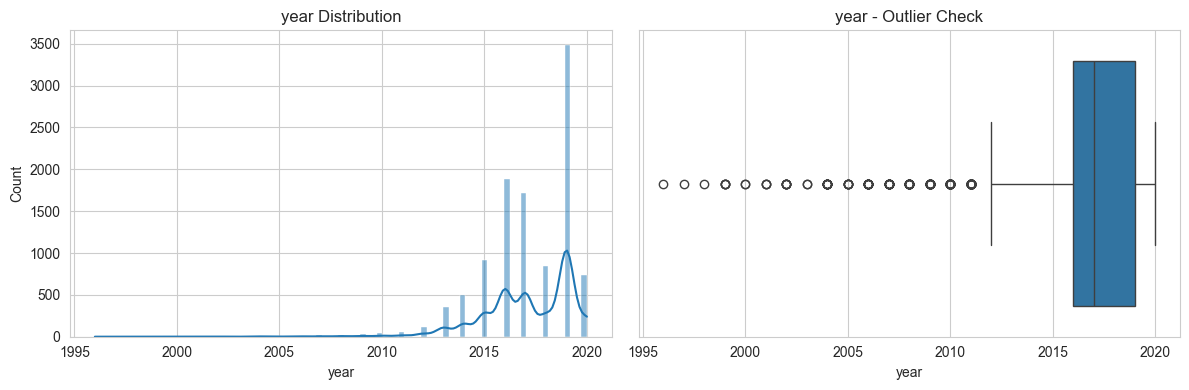

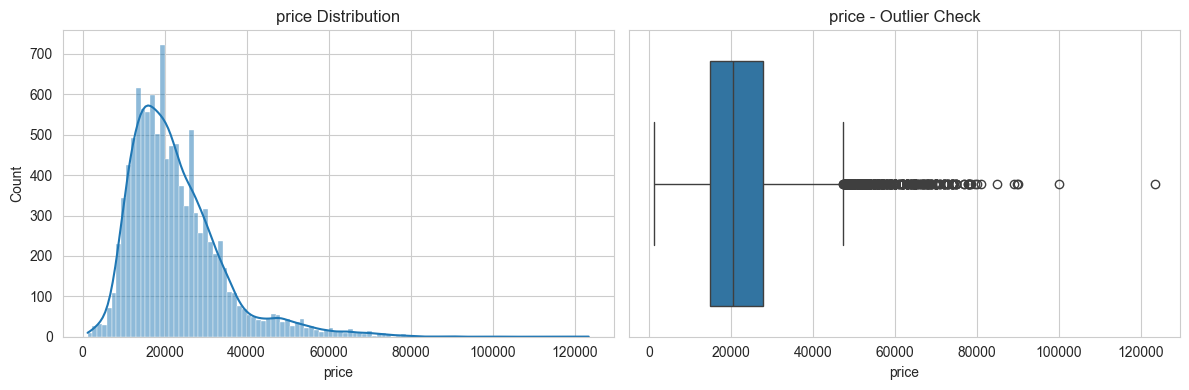

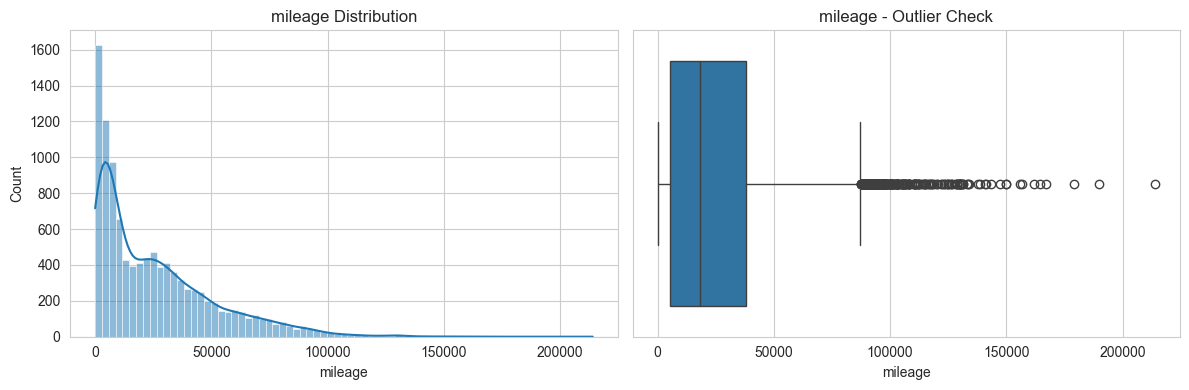

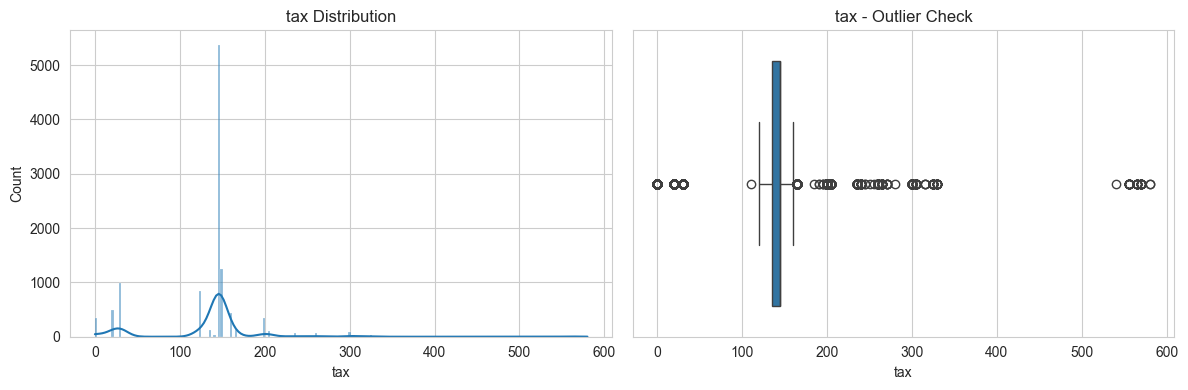

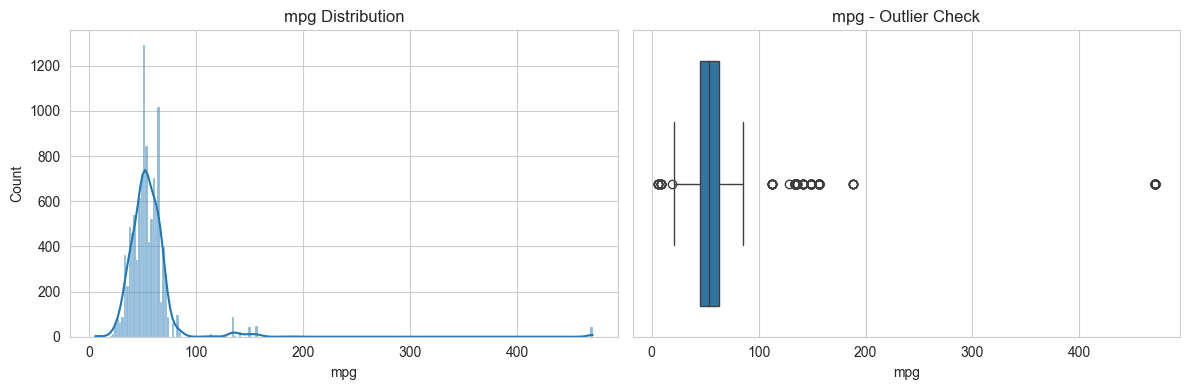

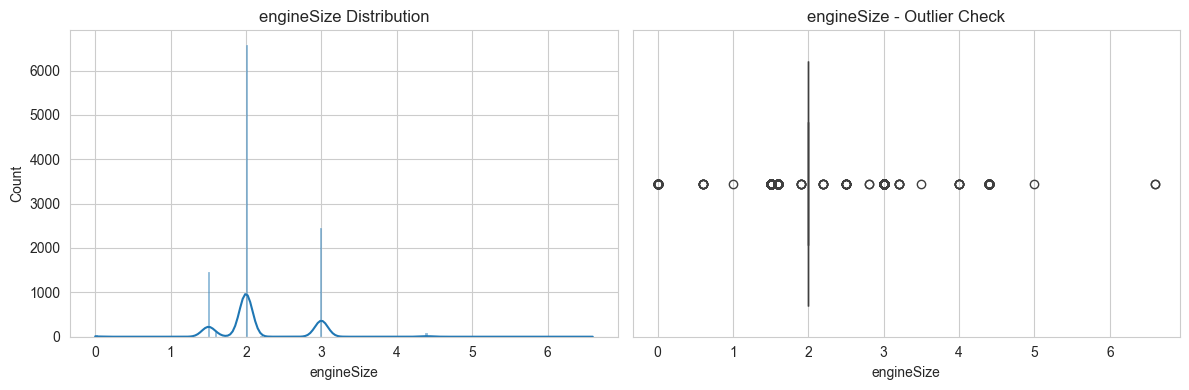

In [14]:
for col in cols_for_hist:
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    sns.histplot(data=df, x=col, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} Distribution")

    sns.boxplot(data=df, x=col, ax=axes[1])
    axes[1].set_title(f"{col} - Outlier Check")

    plt.tight_layout()
    plt.show()

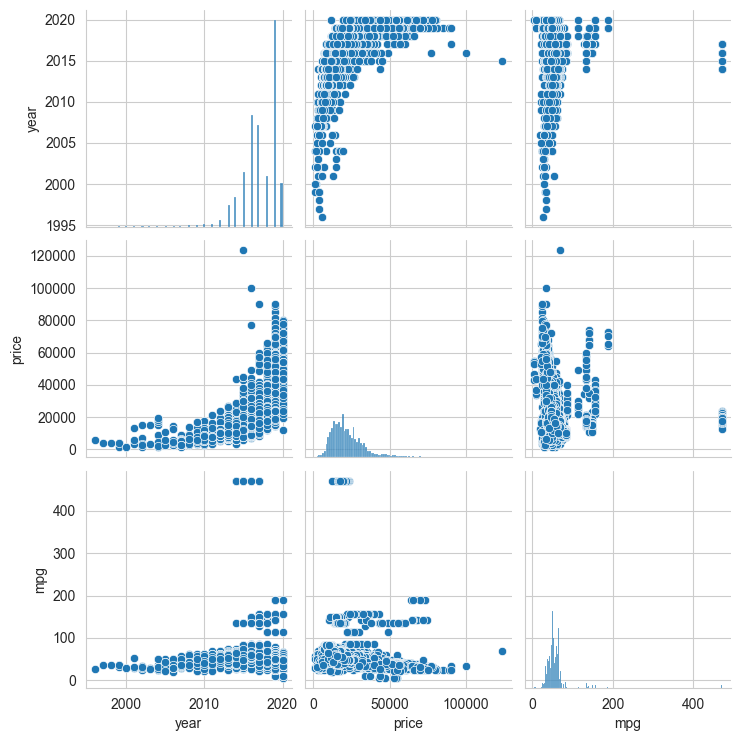

In [15]:
cols_for_pair_plot = ['year', 'price', 'mpg']

sns.pairplot(df[cols_for_pair_plot])
plt.show()

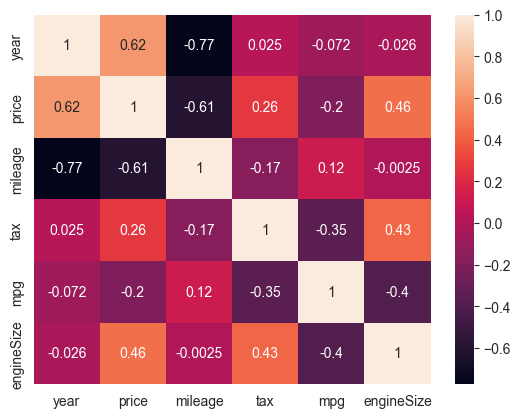

In [16]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
plt.figure()
sns.heatmap(corr_matrix, annot=True)
plt.savefig('Correlation-matrix.png')
plt.show()

In [17]:
df = df[df['fuelType'] != 'Electric']

In [18]:
df[df['engineSize']==0].shape[0]

45

In [19]:
df_clean = df[df['engineSize']>0]

In [20]:
CURRENT_YEAR = 2026
df_clean['car_age'] = CURRENT_YEAR - df_clean['year']
df_clean.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,car_age
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0,12
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0,8
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0,10
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5,9
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0,12


In [21]:
df_clean['log_price'] = np.log(df_clean['price'])

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [23]:
X = df_clean.drop(columns=['price', 'log_price'])
y = df_clean['log_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=99
)


In [24]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

In [26]:
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror",
        n_jobs=-1
    ),
    
    "CatBoost": CatBoostRegressor(
        iterations=600,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_state=42,
        verbose=0
    )
}

In [27]:
final_results = {}
trained_pipelines = {} 

for name, model in models.items():
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    final_results[name] = {
        "RMSE (log)": rmse,
        "MAE (log)": mae,
        "R2": r2
    }
    trained_pipelines[name] = pipe

In [30]:
for model_name, metrics in final_results.items():
    print(f"\n{model_name}")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")


Linear Regression
RMSE (log): 0.1220
MAE (log): 0.0917
R2: 0.9352

Random Forest
RMSE (log): 0.1054
MAE (log): 0.0721
R2: 0.9516

XGBoost
RMSE (log): 0.0979
MAE (log): 0.0700
R2: 0.9583

CatBoost
RMSE (log): 0.0981
MAE (log): 0.0703
R2: 0.9581


In [31]:
y_test_actual = np.exp(y_test)
y_pred_actual = np.exp(pipe.predict(X_test))

rmse_real = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mae_real = mean_absolute_error(y_test_actual, y_pred_actual)

print("RMSE (Real Price):", rmse_real)
print("MAE (Real Price):", mae_real)

RMSE (Real Price): 2475.1722485113933
MAE (Real Price): 1574.7623397134917


In [34]:
trained_pipelines

{'Linear Regression': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age'], dtype='str')),
                                                  ('cat',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore'),
                                                   Index(['model', 'transmission', 'fuelType'], dtype='str'))])),
                 ('model', LinearRegression())]),
 'Random Forest': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   Index(['year', 'mileage', 'tax', 'mpg', 'engineSize', 'car_age'], dtype='str')),
                                                  ('cat',
                                

In [35]:
best_pipe = trained_pipelines['CatBoost']
best_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [36]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    best_pipe,
    X_train,
    y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

rmse_scores = -cv_scores
print('CV RMSE: ', rmse_scores)
print('Mean CV RMSE: ', rmse_scores.mean())
print('Std CV RMSE: ', rmse_scores.std())

CV RMSE:  [0.09230905 0.10198824 0.11168303 0.09688733 0.10056771]
Mean CV RMSE:  0.10068707081034847
Std CV RMSE:  0.006438129749994801


In [37]:
import optuna

In [38]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 300, 1200),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 225),
        'loss_function': 'RMSE',
        'verbose': 0
    }

    model = CatBoostRegressor(**params)

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=5,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )
    return -scores.mean()